In [12]:
import pandas as pd
import seaborn as sns
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sns.set_theme(style="whitegrid")

In [ ]:
path = "../results/isom/"
# exclude = ["100_1000"]
exclude = []

dfs = []
for csv_path in glob.glob(path + "*/output.csv"):
    if any([still_running in csv_path for still_running in exclude]):
        continue
    df = pd.read_csv(csv_path)
    dfs += [df]

df = pd.concat(dfs)

df_isom = df.melt(["n", "k", "id1", "id2"])
df_isom["same_network"] = (df_isom["id1"] == df_isom["id2"])
df_isom['same_network'] = df_isom['same_network'].replace({True: 'yes', False: 'no'})
df_isom['mu'] = df_isom['variable'].replace({'time_mu': 'yes', 'time_no_mu': 'no'})
df_isom = df_isom.drop("variable", axis=1)
print(df_isom.describe())

df["factor"] = (df["time_no_mu"] / df["time_mu"])



                  n             k           id1           id2         value
count  48450.000000  48450.000000  48450.000000  48450.000000  48450.000000
mean     344.210526    239.473684     16.333333     32.666667      2.936722
std      383.153173    394.765477     11.897835     11.897835    139.257414
min       10.000000      0.000000      0.000000      0.000000      0.000598
25%       50.000000      0.000000      6.000000     24.000000      0.005379
50%      100.000000     10.000000     14.000000     35.000000      0.020553
75%      500.000000    100.000000     25.000000     43.000000      0.075020
max     1000.000000   1000.000000     49.000000     49.000000  23787.019394


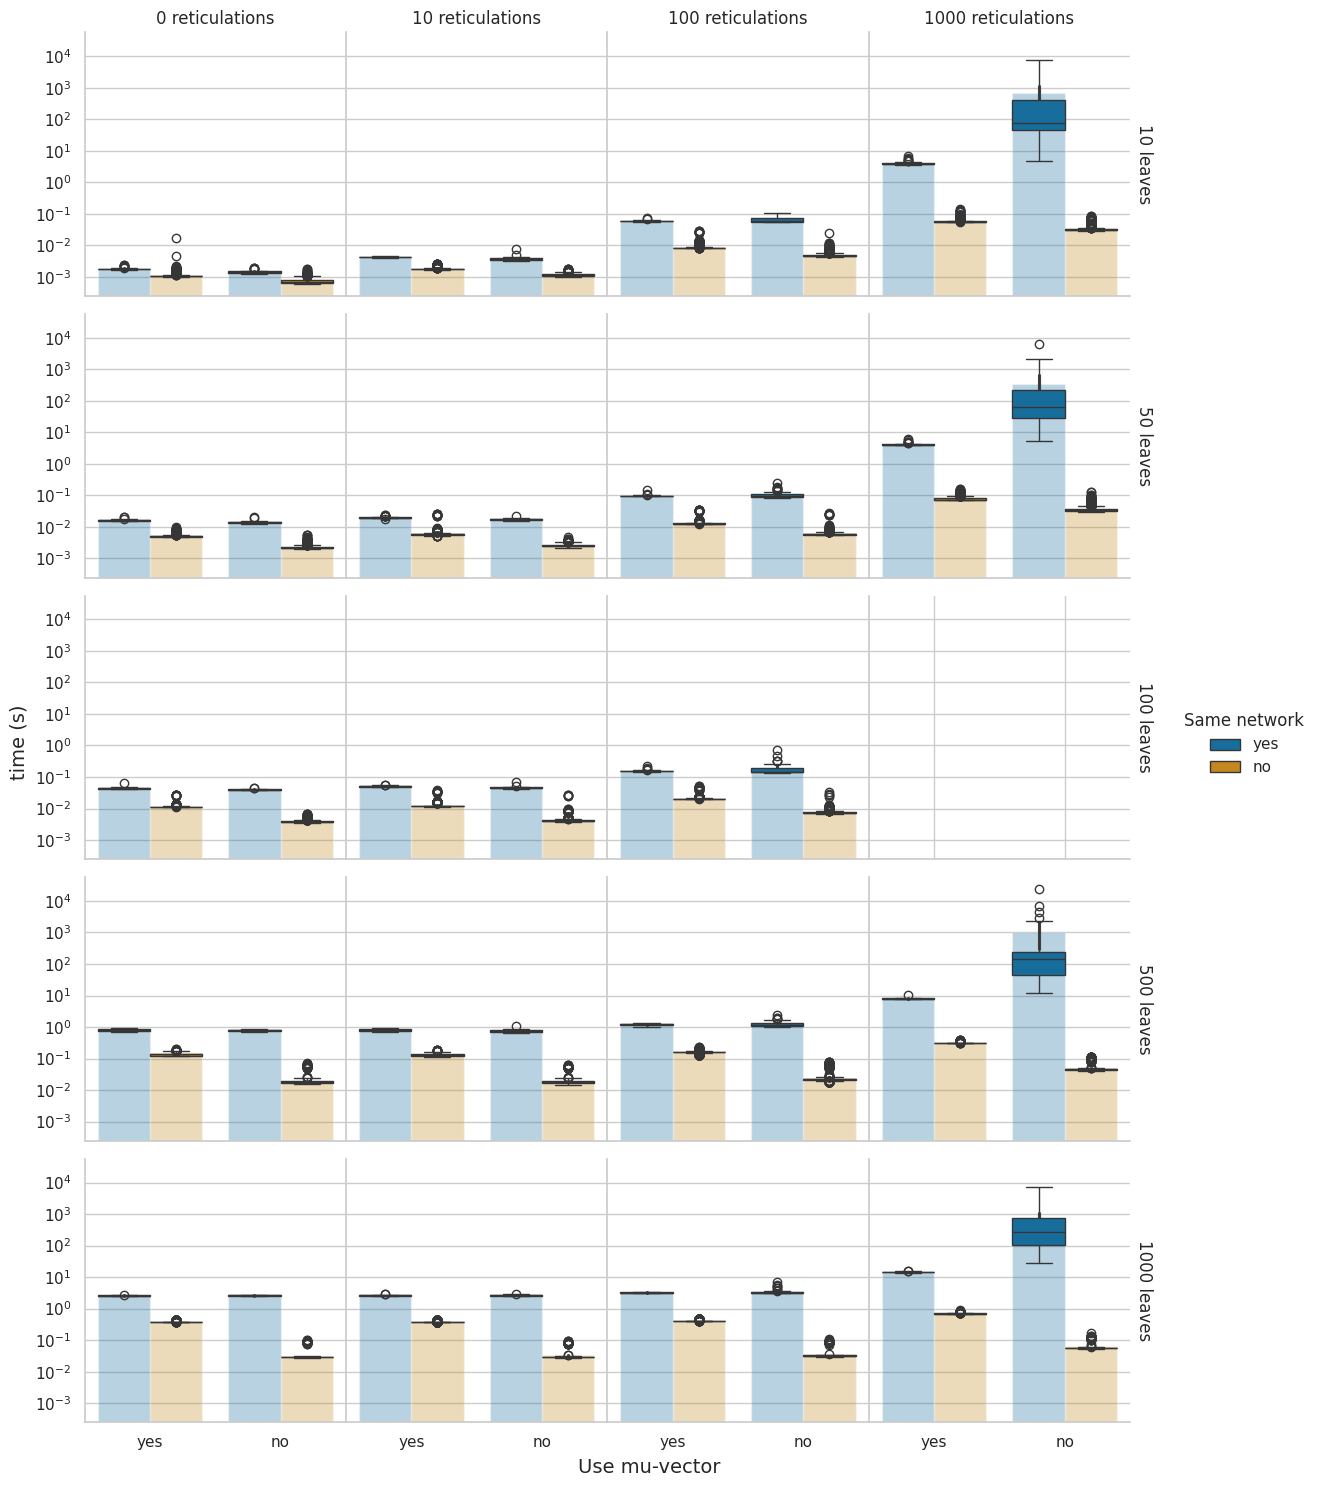

In [27]:
g = sns.FacetGrid(df_isom, col="k", row="n", margin_titles=True)
g.map(sns.barplot, "mu", "value", "same_network", order=["yes", "no"], hue_order=["yes", "no"], palette='colorblind', alpha=0.3).set(yscale = 'log')
g.map(sns.boxplot, "mu", "value", "same_network", order=["yes", "no"], hue_order=["yes", "no"], palette='colorblind').set(yscale = 'log')
g.set_axis_labels("", "")
g.figure.supxlabel("Use mu-vector", fontsize=14)
g.figure.supylabel("time (s)", fontsize=14)
g.set_titles(row_template='{row_name} leaves', col_template='{col_name} reticulations')
g.add_legend(title="Same network")
g.figure.subplots_adjust(wspace=0)
g.tick_params()

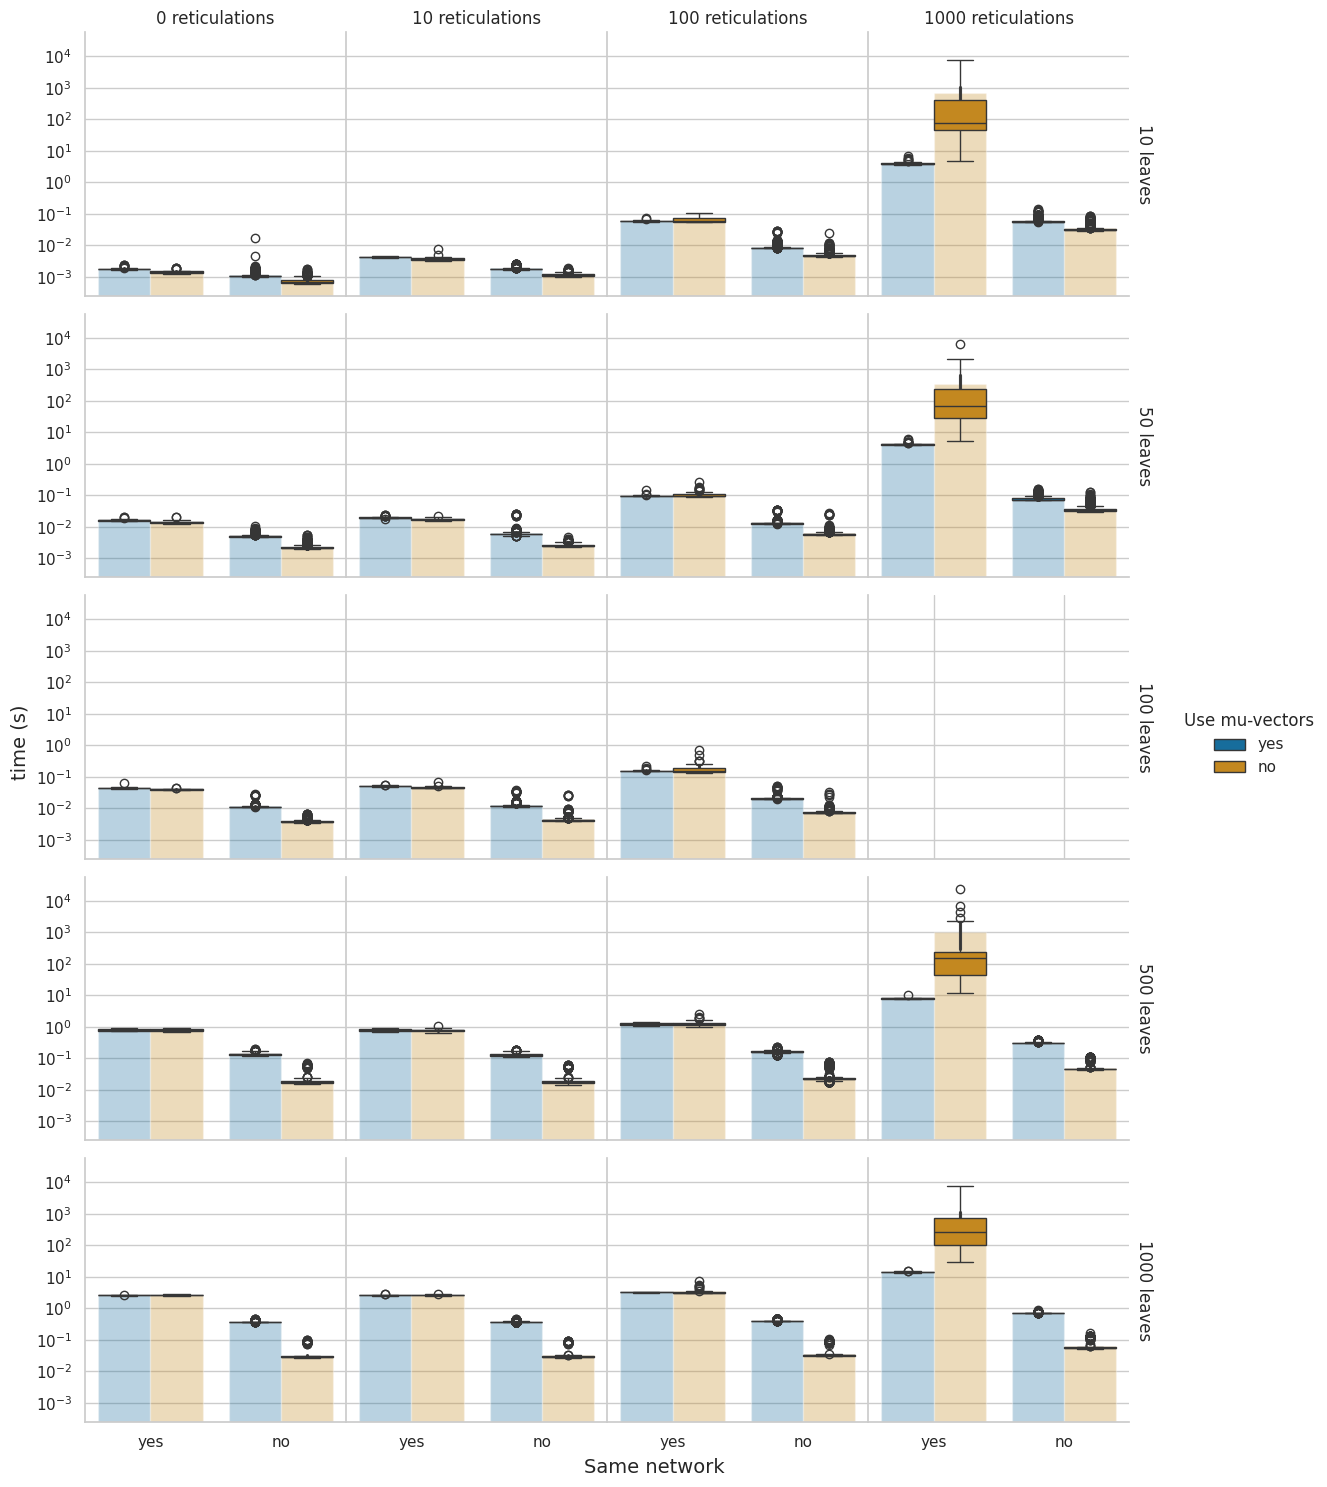

In [28]:
g = sns.FacetGrid(df_isom, col="k", row="n", margin_titles=True)
g.map(sns.barplot, "same_network", "value", "mu", order=["yes", "no"], hue_order=["yes", "no"], palette='colorblind', alpha=0.3).set(yscale = 'log')
g.map(sns.boxplot, "same_network", "value", "mu", order=["yes", "no"], hue_order=["yes", "no"], palette='colorblind').set(yscale = 'log')
g.set_axis_labels("", "")
g.figure.supxlabel("Same network", fontsize=14)
g.figure.supylabel("time (s)", fontsize=14)
g.set_titles(row_template='{row_name} leaves', col_template='{col_name} reticulations')
g.add_legend(title="Use mu-vectors")
g.figure.subplots_adjust(wspace=0)
g.tick_params()

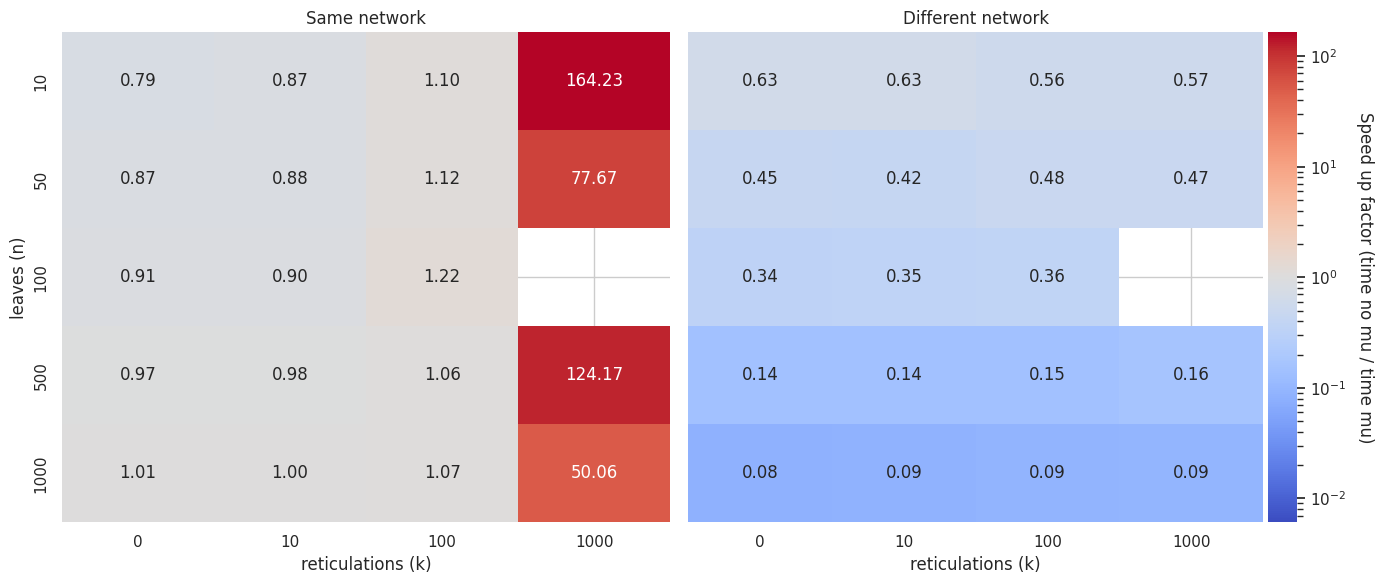

In [29]:
# UNPAIRED MEASUREMENTS DO NOT USE!

pivoted_same = df_isom[df_isom["same_network"]=="yes"].groupby(['n', 'k', 'mu'])['value'].mean().reset_index()
pivoted_different = df_isom[df_isom["same_network"]=="no"].groupby(['n', 'k', 'mu'])['value'].mean().reset_index()

# Compute both diff matrices first
diffs = []
titles = []
for pivoted, title in zip([pivoted_same, pivoted_different], ["Same network", "Different network"]):
    diff = (
        pivoted[pivoted['mu'] == 'no'].set_index(['n','k'])['value'] /
        pivoted[pivoted['mu'] == 'yes'].set_index(['n','k'])['value']
    ).unstack()
    diffs.append(diff)
    titles.append(title)

# Find global min/max for log color scale (avoid zero or negative!)
all_vals = pd.concat([d.stack() for d in diffs])
vmin = all_vals[all_vals>0].min()
vmax = all_vals.max()
vbound = max(vmax, 1/vmin)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Create a single colorbar axis
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)

# Plot both heatmaps
for ax, diff, title in zip(axes, diffs, titles):
    sns.heatmap(
        diff,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        norm=mcolors.LogNorm(vmin=1/vbound, vmax=vbound),
        ax=ax,
        cbar=ax is axes[1],   # Only draw cbar on last axis
        cbar_ax=cax if ax is axes[1] else None
    )
    ax.set_title(title)
    ax.set_xlabel('reticulations (k)')
    if ax is axes[0]:
        ax.set_ylabel('leaves (n)')
    else:
        ax.set_ylabel('')

# Set colorbar label
cax.set_ylabel('Speed up factor (time no mu / time mu)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

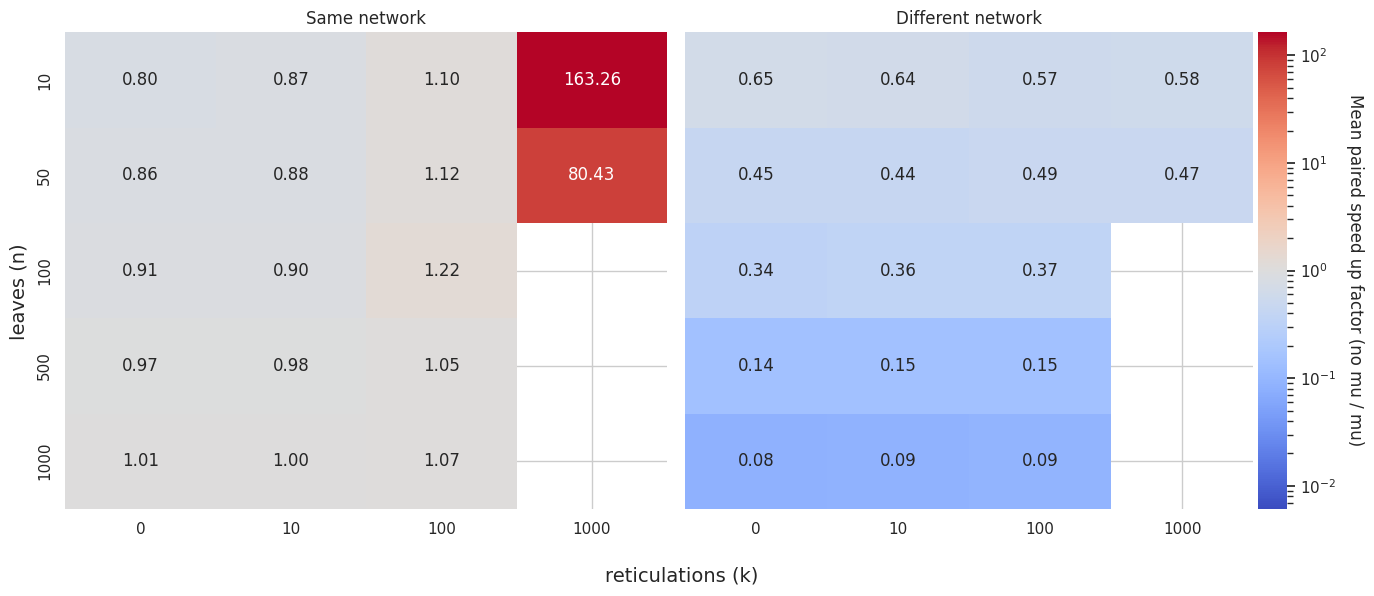

In [24]:
# PAIRED MEASUREMENTS!

mean_factor_same = (
    df[df["id1"] == df["id2"]]
    .groupby(["n", "k"])["factor"]
    .mean()
    .unstack()
)
mean_factor_diff = (
    df[df["id1"] != df["id2"]]
    .groupby(["n", "k"])["factor"]
    .mean()
    .unstack()
)

diffs = [mean_factor_same, mean_factor_diff]
titles = ["Same network", "Different network"]

# Find global min/max for symmetric log color scale around 1
all_vals = pd.concat([d.stack() for d in diffs])
vmin = all_vals[all_vals>0].min()
vmax = all_vals.max()
vbound = max(vmax, 1/vmin)  # So that 1/vbound <= 1 <= vbound, color symmetric

# Prepare the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)

# Plot both heatmaps
for ax, diff, title in zip(axes, diffs, titles):
    sns.heatmap(
        diff,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        norm=mcolors.LogNorm(vmin=1/vbound, vmax=vbound),
        ax=ax,
        cbar=ax is axes[1],
        cbar_ax=cax if ax is axes[1] else None
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Set colorbar label
cax.set_ylabel('Mean paired speed up factor (no mu / mu)', rotation=270, labelpad=20)

# Add a global x/y label (optional, requires matplotlib >=3.4)
fig.supxlabel("reticulations (k)", fontsize=14)
fig.supylabel("leaves (n)", fontsize=14)

plt.tight_layout()
plt.show()